IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

UPLOAD DATASET



In [ ]:
from google.colab import files

uploaded = files.upload()

Saving stores_sales_forecasting.csv to stores_sales_forecasting (1).csv


READ THE DATASET

In [ ]:
df = pd.read_csv('stores_sales_forecasting.csv', encoding='latin1')

CHECKING DATA

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [ ]:
df.shape

(2121, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

CHECKING MISSING VALUES

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

CONVERTING ORDER DTAE

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df[['Order Date', 'Sales']].head()

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2015-10-11,957.5775
3,2014-06-09,48.8600
4,2014-06-09,1706.1840


SORTING DATE BY DATE

In [ ]:
df = df.sort_values('Order Date')

In [ ]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales = daily_sales.set_index('Order Date').asfreq('D')

daily_sales['Sales'] = daily_sales['Sales'].fillna(0)

daily_sales = daily_sales.reset_index()

daily_sales.head()

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-08,0.000
3,2014-01-09,0.000
4,2014-01-10,51.940


VISUALISING SALES TRENDS

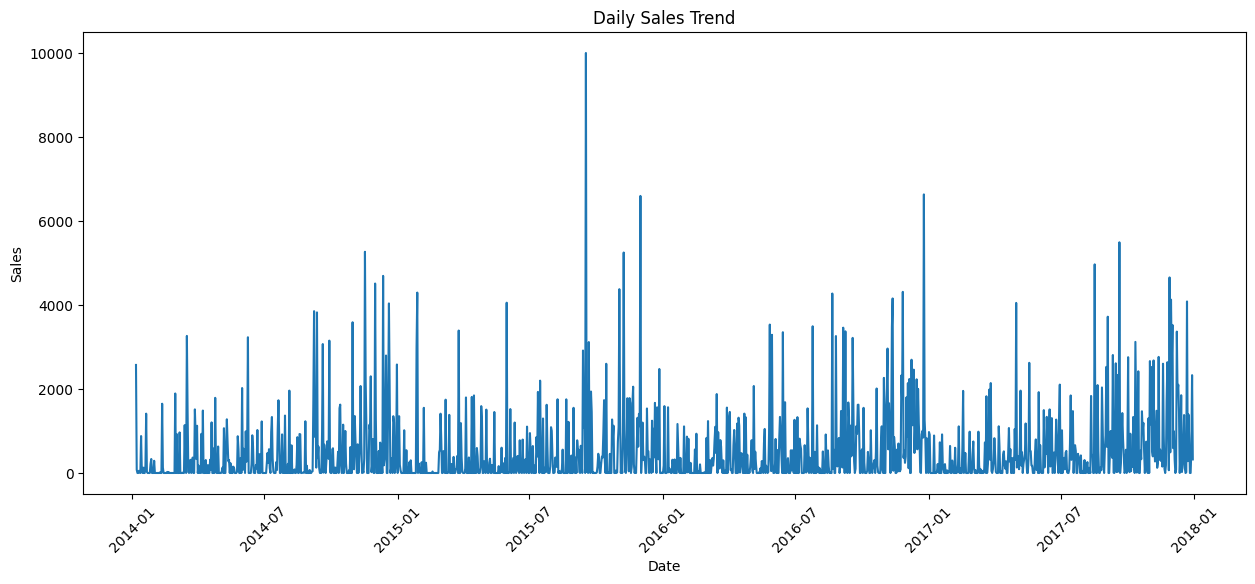

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

MONTHLY SALES ANALYSIS

In [ ]:
monthly_sales = df.resample(
    'ME',
    on='Order Date'
)['Sales'].sum()

In [ ]:
monthly_sales.head()

,Sales
Order Date,
2014-01-31,6242.525
2014-02-28,1839.658
2014-03-31,14573.956
2014-04-30,7944.837
2014-05-31,6912.787


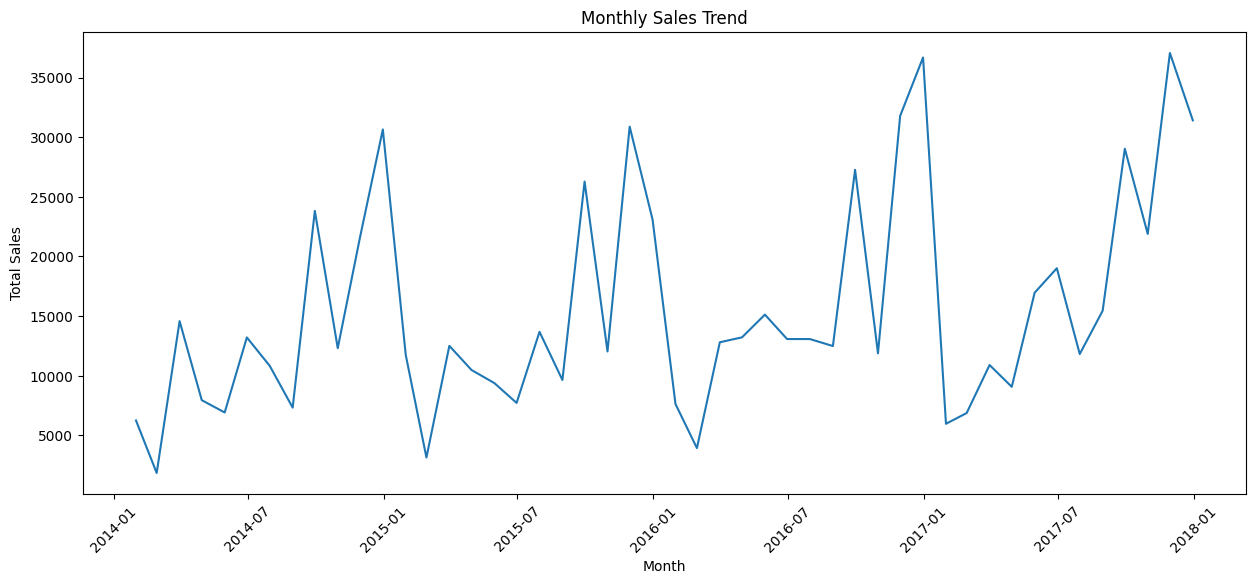

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

In [ ]:
daily_sales = daily_sales.set_index('Order Date').asfreq('D')

daily_sales['Sales'] = daily_sales['Sales'].fillna(0)

daily_sales = daily_sales.reset_index()

INSERTING MACHINE LEARNING FEATURES

In [ ]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year

daily_sales['Month'] = daily_sales['Order Date'].dt.month

daily_sales['Day'] = daily_sales['Order Date'].dt.day

daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

daily_sales['Quarter'] = daily_sales['Order Date'].dt.quarter

In [ ]:
daily_sales.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek,Quarter
0,2014-01-06,2573.820,2014,1,6,0,1
1,2014-01-07,76.728,2014,1,7,1,1
2,2014-01-08,0.000,2014,1,8,2,1
3,2014-01-09,0.000,2014,1,9,3,1
4,2014-01-10,51.940,2014,1,10,4,1


CREATING LAG FEATURES

In [ ]:
daily_sales['Previous_Day_Sales'] = daily_sales['Sales'].shift(1)

In [ ]:
daily_sales['Sales_7_Days_Ago'] = daily_sales['Sales'].shift(7)

In [ ]:
daily_sales['Sales_30_Days_Ago'] = daily_sales['Sales'].shift(30)

In [ ]:
daily_sales = daily_sales.dropna()

SELECTING FEATURES

In [ ]:
features = [
    'Year',
    'Month',
    'Day',
    'DayOfWeek',
    'Quarter',
    'Previous_Day_Sales',
    'Sales_7_Days_Ago',
    'Sales_30_Days_Ago'
]

X = daily_sales[features]

y = daily_sales['Sales']

SPLITING DATA

In [ ]:
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

PERFORMING LINEAR REGRESSION

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
MAE: 638.9634021056237
RMSE: 938.6495260177447
R2 Score: 0.059296742053611795


DECISION TREE MODEL

In [ ]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [ ]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R2 Score:", tree_r2)

Decision Tree
MAE: 714.7703962052552
RMSE: 1123.430798364854
R2 Score: -0.3475297719507242


RANDOM FOREST MODEL

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest
MAE: 617.5919707953389
RMSE: 928.0771259246046
R2 Score: 0.08036846442787404


COMPARING MODELS

In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE': [
        linear_mae,
        tree_mae,
        rf_mae
    ],

    'RMSE': [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],

    'R2 Score': [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,638.963402,938.649526,0.059297
1,Decision Tree,714.770396,1123.430798,-0.347530
2,Random Forest,617.591971,928.077126,0.080368


ACTUAL VS PREDICTED SALES

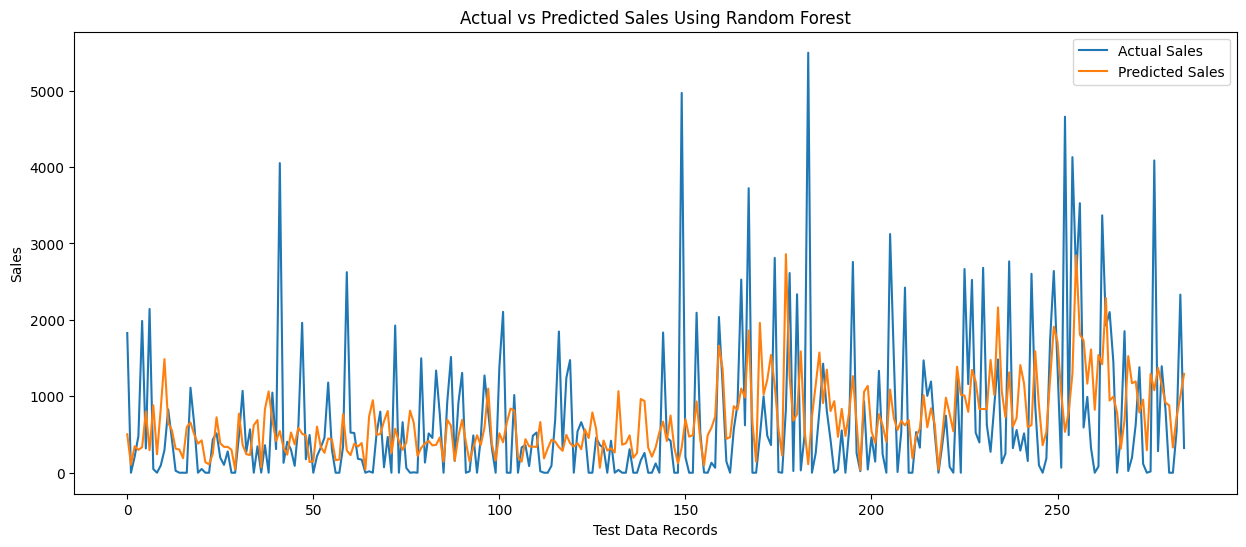

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    rf_predictions,
    label='Predicted Sales'
)

plt.title(
    'Actual vs Predicted Sales Using Random Forest'
)

plt.xlabel('Test Data Records')

plt.ylabel('Sales')

plt.legend()

plt.show()

FEATURE IMPORTANCE

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,Sales_7_Days_Ago,0.222255
2,Day,0.179115
5,Previous_Day_Sales,0.152873
1,Month,0.140361
7,Sales_30_Days_Ago,0.122158
3,DayOfWeek,0.108985
0,Year,0.054768
4,Quarter,0.019485


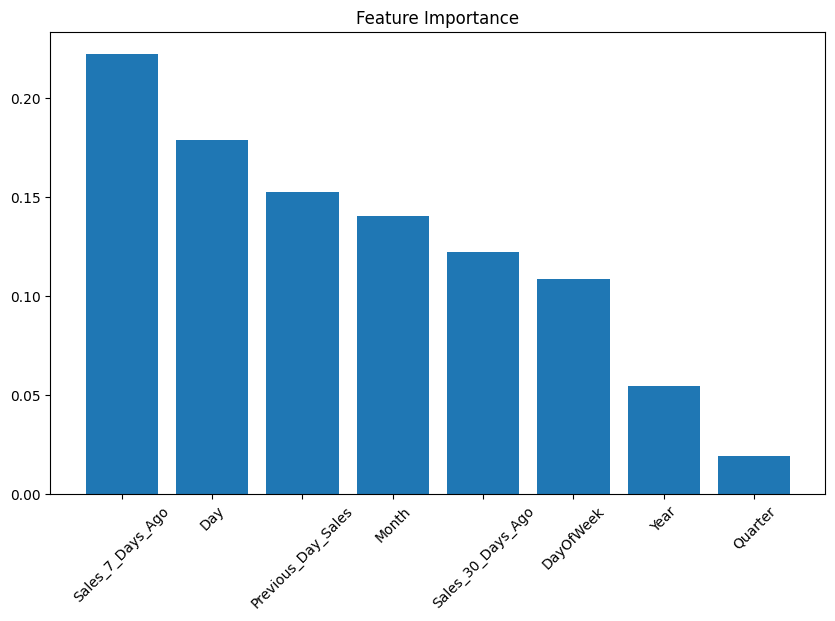

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')

plt.xticks(rotation=45)

plt.show()

PREDICTING FUTURE SALES

In [ ]:
last_date = daily_sales['Order Date'].max()

print("Last date in dataset:", last_date)

Last date in dataset: 2017-12-30 00:00:00


In [ ]:
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

future_df = pd.DataFrame({
    'Order Date': future_dates
})

future_df.head()

,Order Date
0,2017-12-31
1,2018-01-01
2,2018-01-02
3,2018-01-03
4,2018-01-04


In [ ]:
history = daily_sales.copy()

future_predictions = []

for i in range(30):

    next_date = history['Order Date'].max() + pd.Timedelta(days=1)

    previous_day_sales = history.iloc[-1]['Sales']

    sales_7_days_ago = history.iloc[-7]['Sales']

    sales_30_days_ago = history.iloc[-30]['Sales']

    future_features = pd.DataFrame({
        'Year': [next_date.year],
        'Month': [next_date.month],
        'Day': [next_date.day],
        'DayOfWeek': [next_date.dayofweek],
        'Quarter': [next_date.quarter],
        'Previous_Day_Sales': [previous_day_sales],
        'Sales_7_Days_Ago': [sales_7_days_ago],
        'Sales_30_Days_Ago': [sales_30_days_ago]
    })

    predicted_sales = rf_model.predict(
        future_features
    )[0]

    future_predictions.append({
        'Order Date': next_date,
        'Predicted Sales': predicted_sales
    })

    new_row = pd.DataFrame({
        'Order Date': [next_date],
        'Sales': [predicted_sales]
    })

    history = pd.concat(
        [history, new_row],
        ignore_index=True
    )

In [ ]:
forecast_df = pd.DataFrame(
    future_predictions
)

forecast_df

,Order Date,Predicted Sales
0,2017-12-31,1374.203315
1,2018-01-01,471.595100
2,2018-01-02,286.105607
3,2018-01-03,237.084989
4,2018-01-04,312.373107
5,2018-01-05,380.577366
6,2018-01-06,274.998253
7,2018-01-07,757.631082
8,2018-01-08,336.530750
9,2018-01-09,305.892559


ANALYZING 30 DAY FUTURE SALES FORECAST

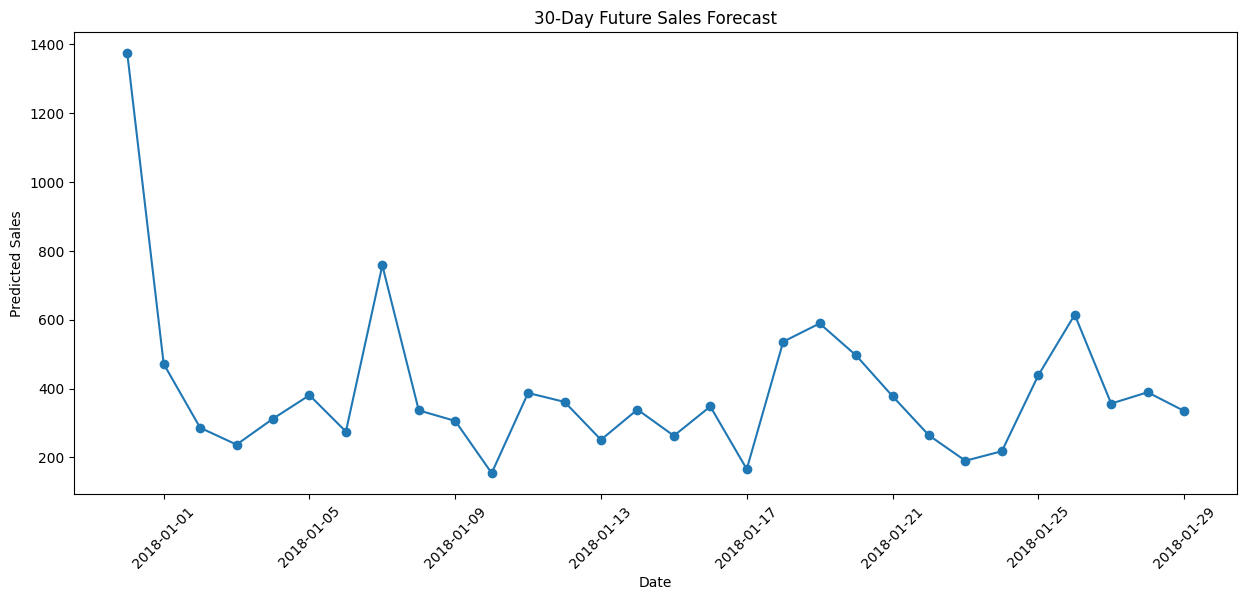

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    forecast_df['Order Date'],
    forecast_df['Predicted Sales'],
    marker='o'
)

plt.title(
    '30-Day Future Sales Forecast'
)

plt.xlabel('Date')

plt.ylabel('Predicted Sales')

plt.xticks(rotation=45)

plt.show()